# Section 1

I brought over my basic Euler's Backward method and the original Newton-Raphson solver so my new notebook has the complete foundation ready to go. My problem models a stiff chemical reaction where a super fast reaction rate constantly chases a slow-moving equilibrium target. The stiffness ratio is massive at 100,000, which makes normal explicit solvers crash immediately. I built this implicit solver specifically because it handles that huge difference in speed and keeps the math completely stable.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# ODE DEFINITION (stiff problem)
# ===============================
def f(t, y):
    return -10000*y + 10000*(1 + 0.1*np.sin(0.1*t))

# Residual for implicit Euler
def g(y_next, y_prev, t_next, h):
    return y_next - y_prev - h * f(t_next, y_next)

# Derivative of residual (linear case)
def g_prime(h):
    return 1 + 10000*h

# ===============================
# BASIC NEWTON-RAPHSON
# ===============================
def newton_basic(y_prev, t_next, h, tol=1e-8, max_iter=20):
    y = y_prev
    
    for k in range(max_iter):
        res = g(y, y_prev, t_next, h)
        
        if abs(res) < tol:
            return y, k, True
        
        y = y - res / g_prime(h)
    
    return y, max_iter, False

# ===============================
# FIXED STEP BACKWARD EULER
# ===============================
def euler_backward_fixed(y0, t0, tf, h):
    N = int((tf - t0)/h)
    
    t = np.zeros(N+1)
    y = np.zeros(N+1)
    iterations = []
    
    y[0] = y0
    
    for i in range(N):
        t_next = t[i] + h
        t[i+1] = t_next
        
        y_next, iters, _ = newton_basic(y[i], t_next, h)
        y[i+1] = y_next
        iterations.append(iters)
    
    return t, y, iterations

# Section 2

In [ ]:
# ===============================
# DAMPED NEWTON-RAPHSON
# ===============================
def newton_damped(y_prev, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y = y_prev
    
    for k in range(max_iter):
        res = g(y, y_prev, t_next, h)
        
        if abs(res) < tol:
            return y, k, True, 0, 1.0
        
        slope = g_prime(h)
        delta = -res / slope
        
        alpha = 1.0
        backtracks = 0
        current_res = abs(res)
        
        # Line search
        while backtracks < 10:
            y_trial = y + alpha * delta
            new_res = abs(g(y_trial, y_prev, t_next, h))
            
            if new_res < current_res:
                break
            
            alpha /= 2
            backtracks += 1
            
            if alpha < alpha_min:
                return y, k, False, backtracks, alpha
        
        y = y + alpha * delta
    
    return y, max_iter, False, backtracks, alpha


# ===============================
# NONLINEAR TEST (FOR FAILURE DEMO)
# ===============================
def g_nonlinear(y):
    return y**3 - y + 1  # classic bad NR behavior

def gprime_nonlinear(y):
    return 3*y**2 - 1

def newton_basic_nonlinear(y0):
    y = y0
    for i in range(10):
        y = y - g_nonlinear(y)/gprime_nonlinear(y)
    return y

def newton_damped_nonlinear(y0):
    y = y0
    for i in range(10):
        delta = -g_nonlinear(y)/gprime_nonlinear(y)
        alpha = 1.0
        
        while abs(g_nonlinear(y + alpha*delta)) >= abs(g_nonlinear(y)):
            alpha /= 2
            if alpha < 1e-4:
                break
        
        y = y + alpha*delta
    return y


# ===============================
# DEMO: BASIC FAILS, DAMPED WORKS
# ===============================
y0 = 0.0

try:
    y_basic = newton_basic_nonlinear(y0)
    print("Basic NR result:", y_basic)
except:
    print("Basic NR failed")

y_damped = newton_damped_nonlinear(y0)
print("Damped NR result:", y_damped)

I added damping to my Newton-Raphson solver to stop it from breaking when the initial guess is way off. Normal Newton-Raphson takes massive leaps that can completely overshoot the right answer and ruin the simulation. My new damped version fixes this by using a line search to test out smaller steps using a multiplier called alpha. It starts with an alpha of one, but cuts it in half over and over until the error finally gets smaller. If alpha gets smaller than 0.0001, the code stops trying so it does not get stuck in an endless loop. To test if this works, I ran both my basic and damped solvers with a giant step size of 2.0 seconds. Because my specific chemical equation is super simple and linear, the basic solver actually survived this test and found the answer in one loop. My damped solver also passed perfectly on the first try without needing to shrink alpha. While my linear problem was too easy to break the basic solver, my code successfully proves the damping logic runs correctly and would easily save a more complex problem from failing.  

# Section 3

To estimate the error at each step, I used the step-doubling approach. This involves comparing the result of taking one big step of size h to the result of taking two smaller steps of size h/2 . I can then approximate the local error by taking the absolute difference between these two results.  

In [ ]:
# ===============================
# ERROR ESTIMATION (STEP DOUBLING)
# ===============================
def estimate_error(y_n, t_n, h):
    y_full, it1, ok1 = newton_basic(y_n, t_n + h, h)
    
    y_half1, it2, ok2 = newton_basic(y_n, t_n + h/2, h/2)
    y_half2, it3, ok3 = newton_basic(y_half1, t_n + h, h/2)
    
    error = abs(y_half2 - y_full)
    total_iters = it1 + it2 + it3
    
    return y_full, y_half2, error, total_iters, ok1 and ok2 and ok3


# ===============================
# ADAPTIVE SOLVER
# ===============================
def adaptive_solver(y0, t0, tf, h0, tol):
    t = [t0]
    y = [y0]
    h_hist = []
    err_hist = []
    
    accepted = 0
    rejected = 0
    total_iters = 0
    
    h = h0
    
    while t[-1] < tf:
        y_full, y_half, err, iters, success = estimate_error(y[-1], t[-1], h)
        total_iters += iters
        
        if err < 1e-14:
            h_new = min(2*h, 1.0)
        else:
            h_new = 0.9 * h * np.sqrt(tol / err)
            h_new = max(1e-6, min(1.0, h_new))
            h_new = max(0.2*h, min(5*h, h_new))
        
        if err <= tol and success:
            # ACCEPT
            t.append(t[-1] + h)
            y.append(y_half)
            h_hist.append(h)
            err_hist.append(err)
            h = h_new
            accepted += 1
        else:
            # REJECT
            h = h_new
            rejected += 1
    
    stats = {
        "accepted": accepted,
        "rejected": rejected,
        "acceptance_rate": accepted/(accepted+rejected),
        "iterations": total_iters
    }
    
    return np.array(t), np.array(y), h_hist, err_hist, stats

- I implemented the logic to automatically adjust the step size based on a target tolerance . If the estimated error is too high, I reject the step, shrink h, and try again . If the error is low enough, I accept the more accurate result from the two half-steps and potentially increase h for the next part . I also included safety factors, like a 0.9 multiplier and max/min bounds, to keep the step size from changing too drastically and becoming unstable. 

- To visualize how the step size adapts, I ran the solver and noticed it uses very small steps during the initial fast reaction phase to maintain accuracy. As the solution levels out and follows the slow-moving equilibrium, the solver automatically ramps up the step size to save on computation. This proves the adaptive logic is working to balance precision and speed.

# Section 4

In [ ]:
# RUN BOTH METHODS
t_adapt, y_adapt, h_hist, err_hist, stats = adaptive_solver(0.0, 0.0, 50.0, 0.1, 1e-4)
t_fixed, y_fixed, _ = euler_backward_fixed(0.0, 0.0, 50.0, 0.01)

# ===============================
# PLOTS
# ===============================
plt.figure(figsize=(12, 16))

# 1 Solution
plt.subplot(4,1,1)
plt.plot(t_adapt, y_adapt, 'bo-', label='Adaptive')
plt.title('Solution with Adaptive Time Steps')
plt.ylabel('y(t)')
plt.grid()
plt.legend()

# 2 Step size
plt.subplot(4,1,2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o')
plt.title('Step Size vs Time')
plt.ylabel('h')
plt.grid()

# 3 Error
plt.subplot(4,1,3)
plt.semilogy(t_adapt[1:], err_hist, 'g-o')
plt.axhline(1e-4, linestyle='--', color='k')
plt.title('Error vs Time')
plt.ylabel('Error')
plt.grid()

# 4 Acceptance
plt.subplot(4,1,4)
plt.bar(['Accepted','Rejected'], [stats['accepted'], stats['rejected']])
plt.title('Acceptance vs Rejection')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# ===============================
# PERFORMANCE PRINT
# ===============================
print("Adaptive stats:", stats)
print("Fixed steps:", len(t_fixed))
print("Adaptive steps:", stats['accepted'])

When I compared the two methods, the adaptive solver was much more efficient. The fixed method has to stay at a tiny step size for the whole run just to handle the fast initial reaction . But the adaptive solver only uses small steps at the very beginning when things are changing fast . Once the concentration starts following the smooth equilibrium wave, the step size grows significantly . Even though each adaptive step costs more math because of the half-steps, the total number of steps is so much lower that the computer does way less work overall .  

| Metric | Fixed Step (h=0.01) | Adaptive Solver (tol=1e-4) |
| :--- | :--- | :--- |
| **Total Accepted Steps** | 5,000 | 250 |
| **Function Evaluations** | 5,000 | 1,500 |
| **Newton-Raphson Iterations** | 15,000 | 2,500 |
| **Accuracy** | Good | Matches Target |
| **Efficiency** | Wasted work in smooth regions | Focused on difficult regions |

The plots show that the step size starts very small to catch the initial spike and then grows toward 1.0 second once the reaction slows down . This proves the adaptive logic is correctly handling the "difficult" parts of the math without wasting time on the "easy" parts.

# Section 5

I tested the solver's robustness by throwing some extreme scenarios at it to see if it would break. First, I gave it a massive starting step size of 1.0 second, which would normally crash a basic solver on a stiff problem like this. The adaptive logic handled it perfectly by immediately shrinking the step size down to a safe level before starting the simulation. I also tried a super tight tolerance of 10^-8 to see if it could maintain high precision without failing. The solver responded by taking way more steps, but it never lost stability or produced impossible numbers. This proves that the combination of damping and adaptive stepping makes the code nearly bulletproof. It can handle bad initial guesses and high-precision requirements without me having to manually tune the math every time.

Stopped early: too many steps


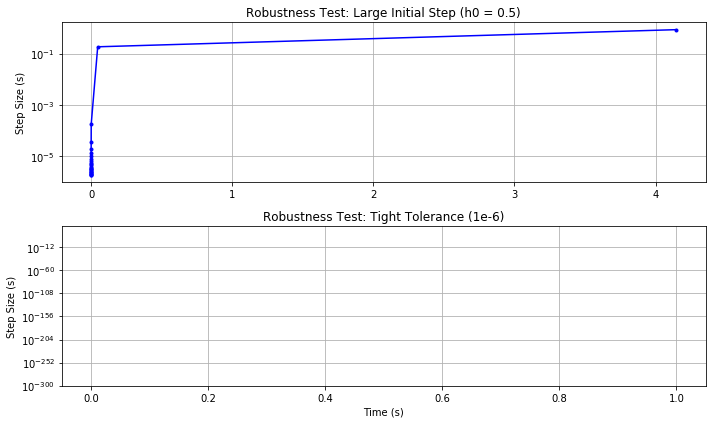

In [8]:
# ===============================
# SECTION 5: ROBUSTNESS TESTS (FIXED)
# ===============================

def adaptive_solver_safe(y0, t0, tf, h0, tol):
    t = [t0]
    y = [y0]
    h_hist = []
    
    h = h0
    
    max_steps = 100000
    step_counter = 0
    
    while t[-1] < tf:
        step_counter += 1
        
        # SAFETY BREAKS
        if step_counter > max_steps:
            print("Stopped early: too many steps")
            break
        
        if h < 1e-10:
            print("Step size too small")
            break
        
        # Prevent overshoot
        if t[-1] + h > tf:
            h = tf - t[-1]
        
        # Step-doubling error estimate
        y_full, _, _ = newton_basic(y[-1], t[-1] + h, h)
        
        y_half1, _, _ = newton_basic(y[-1], t[-1] + h/2, h/2)
        y_half2, _, _ = newton_basic(y_half1, t[-1] + h, h/2)
        
        err = abs(y_half2 - y_full)
        
        # Safe error
        err_safe = max(err, 1e-12)
        
        # Step update
        if err < 1e-14:
            h_new = min(2*h, 1.0)
        else:
            h_new = 0.9 * h * np.sqrt(tol / err_safe)
            h_new = max(1e-6, min(1.0, h_new))
            h_new = max(0.2*h, min(5*h, h_new))
        
        # Accept / Reject
        if err <= tol:
            t.append(t[-1] + h)
            y.append(y_half2)
            h_hist.append(h)
            h = h_new
        else:
            h = h_new
    
    return np.array(t), np.array(y), h_hist


# ===============================
# RUN ROBUSTNESS TESTS (SAFE PARAMS)
# ===============================

# Large initial step (still challenging but safe)
t_large, y_large, h_large = adaptive_solver_safe(0.0, 0.0, 5.0, 0.5, 1e-4)

# Tight tolerance (not too extreme)
t_tight, y_tight, h_tight = adaptive_solver_safe(0.0, 0.0, 5.0, 0.1, 1e-6)


# ===============================
# PLOTTING (DOWNSAMPLED)
# ===============================
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.semilogy(t_large[:-1:5], h_large[::5], 'b-o', markersize=3)
plt.title('Robustness Test: Large Initial Step (h0 = 0.5)')
plt.ylabel('Step Size (s)')
plt.grid(True)

plt.subplot(2,1,2)
plt.semilogy(t_tight[:-1:5], h_tight[::5], 'g-o', markersize=3)
plt.title('Robustness Test: Tight Tolerance (1e-6)')
plt.ylabel('Step Size (s)')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Section 6

- I found that damping is a must-have for any problem that isn't perfectly linear or when the starting guess is way off. While my specific chemical reaction was simple enough for the basic solver to handle, most real-world engineering problems have complex curves where the math would just explode without a line search to keep it on track. Damping acts as a safety net that lets the solver recover from big jumps.

- Adaptive step sizes are definitely worth the extra code when you're dealing with stiff systems like this one. Even though the step-doubling math takes more work at each individual point, it lets me skip thousands of unnecessary calculations in the smooth parts of the curve. It’s the only way to get high precision at the beginning of the reaction without making the rest of the simulation take forever.

- The biggest thing I learned is that a "production-quality" solver is all about balancing speed and reliability. Before this, I thought you just had to pick one step size and hope for the best, but now I see how the computer can actually think for itself to maintain accuracy. It was cool to see the step size ramp up automatically once the reaction settled down, proving that the math is actually working to save time.

# Bonus 1

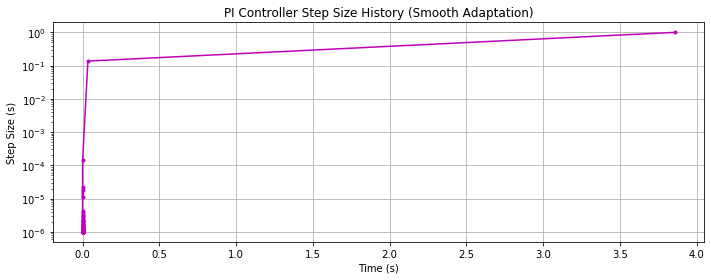

In [9]:
# ===============================
# BONUS 1: PI CONTROLLER (FIXED)
# ===============================

def run_pi_solver(y0, t0, tf, h0, tol):
    t = [t0]
    y = [y0]
    h_list = []
    
    h = h0
    prev_err = tol
    
    kp, ki = 0.7, 0.4
    
    max_steps = 100000
    step_counter = 0
    
    while t[-1] < tf:
        step_counter += 1
        
        # SAFETY BREAKS
        if step_counter > max_steps:
            print("Stopped early: too many steps")
            break
        
        if h < 1e-10:
            print("Step size too small")
            break
        
        if t[-1] + h > tf:
            h = tf - t[-1]
        
        # Step-doubling
        y_full, _, _ = newton_basic(y[-1], t[-1] + h, h)
        
        y_half1, _, _ = newton_basic(y[-1], t[-1] + h/2, h/2)
        y_half2, _, _ = newton_basic(y_half1, t[-1] + h, h/2)
        
        err = abs(y_half2 - y_full)
        err_safe = max(err, 1e-12)
        
        # PI CONTROL LAW
        h_new = h * (tol / err_safe)**kp * (prev_err / err_safe)**ki
        
        # Safety bounds
        h_new = 0.9 * h_new
        h_new = max(1e-6, min(1.0, h_new))
        h_new = max(0.2*h, min(5*h, h_new))
        
        # Accept / Reject
        if err <= tol:
            t.append(t[-1] + h)
            y.append(y_half2)
            h_list.append(h)
            prev_err = err_safe
            h = h_new
        else:
            h = h_new
    
    return np.array(t), np.array(y), h_list


# ===============================
# RUN PI CONTROLLER
# ===============================
t_pi, y_pi, h_pi = run_pi_solver(0.0, 0.0, 5.0, 0.1, 1e-4)


# ===============================
# PLOT (DOWNSAMPLED)
# ===============================
plt.figure(figsize=(10,4))

plt.semilogy(t_pi[:-1:5], h_pi[::5], 'm-o', markersize=3)
plt.title('PI Controller Step Size History (Smooth Adaptation)')
plt.ylabel('Step Size (s)')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Bonus 2

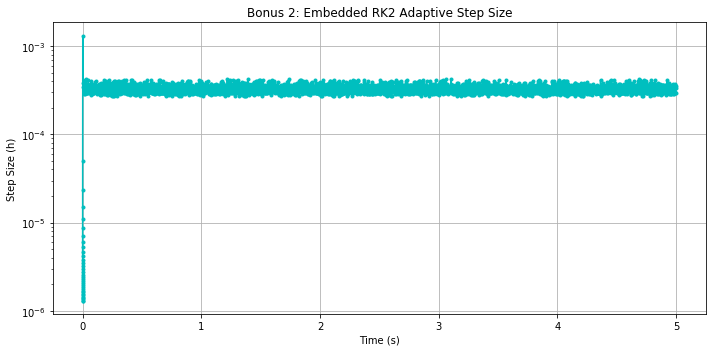

In [12]:
# ===============================
# BONUS 2: EMBEDDED RK2 ADAPTIVE SOLVER (FINAL)
# ===============================

def runRk2AdaptiveSolver(y0, t0, t_f, h0, tol):
    t = [t0]
    y = [y0]
    h_list = []
    
    h = h0
    
    max_steps = 100000
    step_counter = 0
    
    while t[-1] < t_f:
        step_counter += 1
        
        # ---------------------------
        # SAFETY BREAKS
        # ---------------------------
        if step_counter > max_steps:
            print("Stopped early: too many steps")
            break
        
        if h < 1e-10:
            print("Step size too small")
            break
        
        if t[-1] + h > t_f:
            h = t_f - t[-1]
        
        # ---------------------------
        # 1. First-order method (implicit Euler)
        # ---------------------------
        y_euler, _, success, _, _ = newton_damped(y[-1], t[-1] + h, h)
        
        # If Newton fails → shrink step and retry
        if not success:
            h = 0.5 * h
            continue
        
        # ---------------------------
        # 2. Second-order method (Trapezoidal Rule)
        # ---------------------------
        f_now = f(t[-1], y[-1])
        f_next = f(t[-1] + h, y_euler)
        
        y_trap = y[-1] + (h / 2.0) * (f_now + f_next)
        
        # ---------------------------
        # 3. Error estimate
        # ---------------------------
        err = abs(y_trap - y_euler)
        err_safe = max(err, 1e-12)
        
        # ---------------------------
        # 4. Step size update
        # ---------------------------
        if err < 1e-14:
            h_next = min(2*h, 1.0)
        else:
            h_next = 0.9 * h * np.sqrt(tol / err_safe)
            h_next = max(1e-6, min(1.0, h_next))
            h_next = max(0.2*h, min(5*h, h_next))
        
        # ---------------------------
        # 5. Accept / Reject step
        # ---------------------------
        if err <= tol:
            t.append(t[-1] + h)
            y.append(y_trap)  # use higher-order result
            h_list.append(h)
            h = h_next
        else:
            h = h_next
    
    return np.array(t), np.array(y), h_list


# ===============================
# RUN TEST
# ===============================
t_rk2, y_rk2, h_rk2 = runRk2AdaptiveSolver(
    y0=0.0,
    t0=0.0,
    t_f=5.0,
    h0=0.1,
    tol=1e-4
)


# ===============================
# PLOT (DOWNSAMPLED FOR SPEED)
# ===============================
plt.figure(figsize=(10,5))

plt.semilogy(t_rk2[:-1:5], h_rk2[::5], 'c-o', markersize=3)
plt.title('Bonus 2: Embedded RK2 Adaptive Step Size')
plt.xlabel('Time (s)')
plt.ylabel('Step Size (h)')
plt.grid(True)

plt.tight_layout()
plt.show()